First Five Records:
    invoice_id branch       city customer_type gender_customer  \
0  750-67-8428      A     Yangon        Member          Female   
1  226-31-3081      C  Naypyitaw        Normal          Female   
2  631-41-3108      A     Yangon        Normal            Male   
3  123-19-1176      A     Yangon        Member            Male   
4  373-73-7910      A     Yangon        Normal            Male   

             product_line  unit_cost  quantity  5pct_markup   revenue  \
0       Health and beauty      74.69         7      26.1415  548.9715   
1  Electronic accessories      15.28         5       3.8200   80.2200   
2      Home and lifestyle      46.33         7      16.2155  340.5255   
3       Health and beauty      58.22         8      23.2880  489.0480   
4       Sports and travel      86.31         7      30.2085  634.3785   

        date   time payment_method    cogs    gm_pct  gross_income  rating  
0   01/05/19  13:08        Ewallet  522.83  4.761905       26.1415 

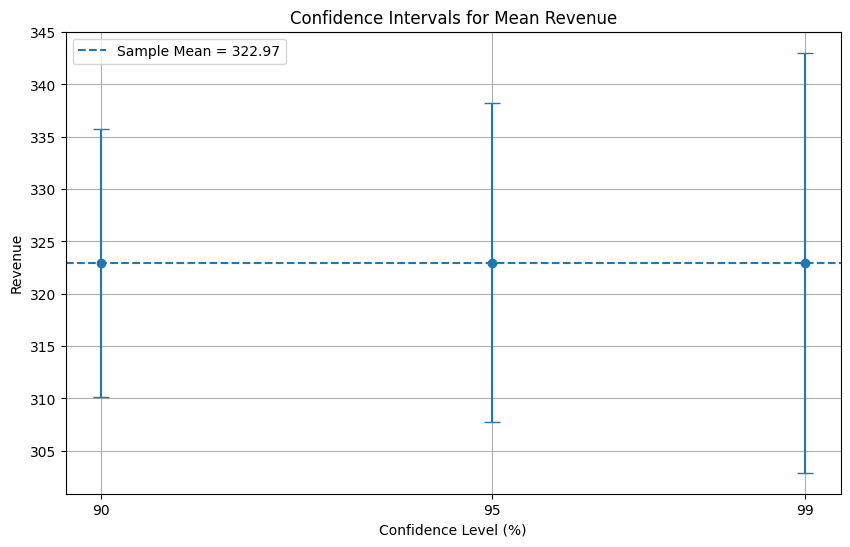


Customer Type Proportions:
customer_type
Member    0.501
Normal    0.499
Name: proportion, dtype: float64

Member Proportion: 0.501
95% CI for Member Proportion:
Lower: 0.47001031036433716
Upper: 0.5319896896356628

Original Sample Median: 253.848


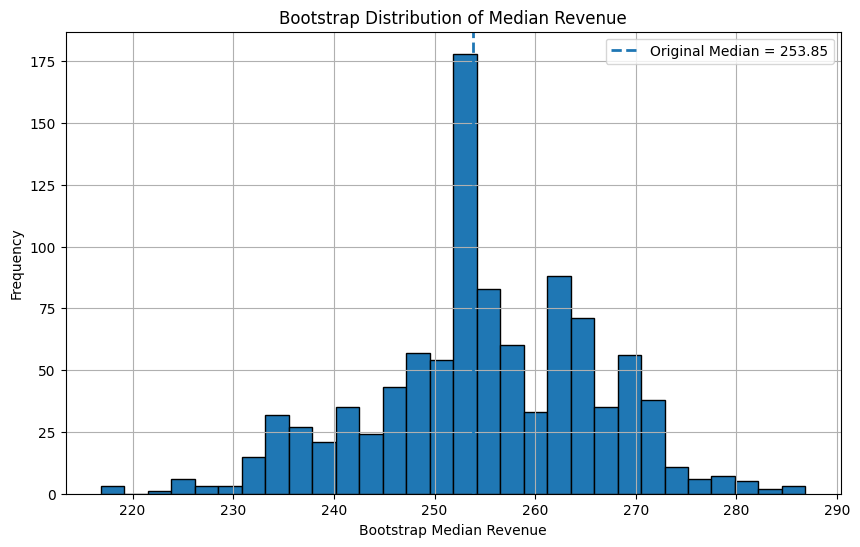


95% Bootstrap Confidence Interval:
Lower Bound: 232.869
Upper Bound: 273.61372500000004

Original Sample Median: 253.848
95% Bootstrap CI: (232.869, 273.614)

The original median lies within the bootstrap confidence interval.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# ==========================================
# PART A: CONFIDENCE INTERVAL ESTIMATION
# ==========================================
# 1. Load dataset
df = pd.read_csv("supermarket_sales.csv")
# 2. Display first five records and dataset size
print("First Five Records:")
print(df.head())
print("\nDataset Size:")
print(df.shape)
# 3. Select revenue column
revenue = df["revenue"]
# 4. Check and handle missing values
print("\nMissing Values in Revenue:", revenue.isnull().sum())
# Remove missing values
revenue = revenue.dropna()
# 5. Calculate sample size, mean and standard deviation
n = len(revenue)
sample_mean = revenue.mean()
sample_std = revenue.std(ddof=1)
print("\nSample Size:", n)
print("Sample Mean:", sample_mean)
print("Sample Standard Deviation:", sample_std)
# 6, 7, 8. Calculate confidence intervals
confidence_levels = [0.90, 0.95, 0.99]
results = []
for confidence in confidence_levels:
    alpha = 1 - confidence
    t_critical = stats.t.ppf(
        1 - alpha / 2,
        df=n-1
    )    
    margin_error = (
        t_critical * sample_std / np.sqrt(n)
    )
    lower = sample_mean - margin_error
    upper = sample_mean + margin_error
    results.append([
        f"{confidence*100:.0f}%",
        lower,
        upper
    ])
# 9. Display confidence intervals in table
ci_table = pd.DataFrame(
    results,
    columns=["Confidence Level", "Lower Bound", "Upper Bound"]
)
print("\nConfidence Intervals:")
print(ci_table.to_string(index=False))
# 10. Compare confidence intervals
print("\nComparison:")
print("Higher confidence levels produce wider confidence intervals.")
# 11. Visualization
levels = [90, 95, 99]
lower_bounds = [x[1] for x in results]
upper_bounds = [x[2] for x in results]
errors_lower = [
    sample_mean - x for x in lower_bounds
]
errors_upper = [
    x - sample_mean for x in upper_bounds
]
plt.figure(figsize=(10, 6))
plt.errorbar(
    levels,
    [sample_mean] * 3,
    yerr=[errors_lower, errors_upper],
    fmt='o',
    capsize=6
)
plt.axhline(
    sample_mean,
    linestyle='--',
    label=f"Sample Mean = {sample_mean:.2f}"
)
plt.xlabel("Confidence Level (%)")
plt.ylabel("Revenue")
plt.title("Confidence Intervals for Mean Revenue")
plt.xticks(levels)
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# CUSTOMER TYPE PROPORTION
# ==========================================
# 13. Calculate proportion of each customer type
customer_proportion = df["customer_type"].value_counts(
    normalize=True
)
print("\nCustomer Type Proportions:")
print(customer_proportion)
# Number of Member customers
member_count = (
    df["customer_type"] == "Member"
).sum()
total_customers = df["customer_type"].notna().sum()
member_proportion = member_count / total_customers
# 14. 95% CI for Member proportion
z_critical = stats.norm.ppf(0.975)
margin = z_critical * np.sqrt(
    member_proportion *
    (1 - member_proportion) /
    total_customers
)
lower_prop = member_proportion - margin
upper_prop = member_proportion + margin
print("\nMember Proportion:", member_proportion)
print("95% CI for Member Proportion:")
print("Lower:", lower_prop)
print("Upper:", upper_prop)
# ==========================================
# PART B: BOOTSTRAPPING
# ==========================================
# 1. Original sample median
original_median = np.median(revenue)
print("\nOriginal Sample Median:", original_median)
# 2-4. Bootstrap sampling
np.random.seed(42)
bootstrap_medians = []
for i in range(1000):
    bootstrap_sample = np.random.choice(
        revenue,
        size=len(revenue),
        replace=True
    )
    # 3. Calculate bootstrap median
    bootstrap_median = np.median(
        bootstrap_sample
    )
    bootstrap_medians.append(
        bootstrap_median
    )
bootstrap_medians = np.array(
    bootstrap_medians
)
# 5. Histogram
plt.figure(figsize=(10, 6))
plt.hist(
    bootstrap_medians,
    bins=30,
    edgecolor="black"
)
plt.axvline(
    float(original_median),
    linestyle="--",
    linewidth=2,
    label=f"Original Median = {float(original_median):.2f}"
)
plt.xlabel("Bootstrap Median Revenue")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Median Revenue")
plt.legend()
plt.grid(True)
plt.show()
# 6. Calculate percentiles
lower_bootstrap = np.percentile(
    bootstrap_medians,
    2.5
)
upper_bootstrap = np.percentile(
    bootstrap_medians,
    97.5
)
# 7. 95% bootstrap confidence interval
print("\n95% Bootstrap Confidence Interval:")
print("Lower Bound:", lower_bootstrap)
print("Upper Bound:", upper_bootstrap)
# 8. Display original median and CI
print("\nOriginal Sample Median:", original_median)
print(
    f"95% Bootstrap CI: "
    f"({lower_bootstrap:.3f}, "
    f"{upper_bootstrap:.3f})"
)
# 9. Compare
if lower_bootstrap <= original_median <= upper_bootstrap:
    print(
        "\nThe original median lies within "
        "the bootstrap confidence interval."
    )
else:
    print(
        "\nThe original median lies outside "
        "the bootstrap confidence interval."
    )
